# Notebook 01 — Exploratory Data Analysis: EMO-DB

**Thesis**: *Designing a Speech Analytics System for Emotions in Employee–Customer Interactions*  
**Author**: Akash Biswas | Allianz / KIT / BHT Berlin 2026

## Goals
1. File inventory: count per emotion class, per speaker, total duration
2. Class imbalance visualization → justifies **Weighted F1** as primary metric
3. Waveform + spectrogram visualizations per emotion class
4. F0 / pitch distribution per emotion (EMO-DB's most discriminative feature)
5. ZCR and energy distributions
6. Speaker statistics (gender, age balance)

In [8]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from pathlib import Path

from src.data_loader import EmoDB_Loader
from src.utils import load_config, set_seed

set_seed(42)
sns.set_theme(style='whitegrid', palette='muted')
cfg = load_config('../configs/config.yaml')

EMODB_RAW = Path('../') / cfg['data']['emodb_raw']
EMODB_PROC = Path('../') / cfg['data']['emodb_processed']
print(f'EMO-DB raw dir: {EMODB_RAW}')

EMO-DB raw dir: ../data/emodb/raw


## 1. Load Manifest

In [2]:
loader = EmoDB_Loader()
df = loader.load_manifest(EMODB_RAW)
print(f'Total files: {len(df)}')
df.head(10)

[2026-04-08 15:46:59] INFO     src.data_loader — EMO-DB manifest: 535 files loaded, 0 skipped. Classes: {'anger': 127, 'boredom_calm': 81, 'neutral': 79, 'happiness': 71, 'fear': 69, 'sadness': 62, 'disgust': 46}


Total files: 535


,filepath,filename,speaker_id,text_code,emotion_code,emotion_label_de,emotion_label_en
0,/home/jovyan/thesis/Masters-Thesis-Voice-AI/da...,03a01Fa.wav,03,a01,F,Freude,happiness
1,/home/jovyan/thesis/Masters-Thesis-Voice-AI/da...,03a01Nc.wav,03,a01,N,Neutral,neutral
2,/home/jovyan/thesis/Masters-Thesis-Voice-AI/da...,03a01Wa.wav,03,a01,W,Ärger,anger
3,/home/jovyan/thesis/Masters-Thesis-Voice-AI/da...,03a02Fc.wav,03,a02,F,Freude,happiness
4,/home/jovyan/thesis/Masters-Thesis-Voice-AI/da...,03a02Nc.wav,03,a02,N,Neutral,neutral
5,/home/jovyan/thesis/Masters-Thesis-Voice-AI/da...,03a02Ta.wav,03,a02,T,Trauer,sadness
6,/home/jovyan/thesis/Masters-Thesis-Voice-AI/da...,03a02Wb.wav,03,a02,W,Ärger,anger
7,/home/jovyan/thesis/Masters-Thesis-Voice-AI/da...,03a02Wc.wav,03,a02,W,Ärger,anger
8,/home/jovyan/thesis/Masters-Thesis-Voice-AI/da...,03a04Ad.wav,03,a04,A,Angst,fear
9,/home/jovyan/thesis/Masters-Thesis-Voice-AI/da...,03a04Fd.wav,03,a04,F,Freude,happiness


## 2. Class Distribution (Imbalance Analysis)

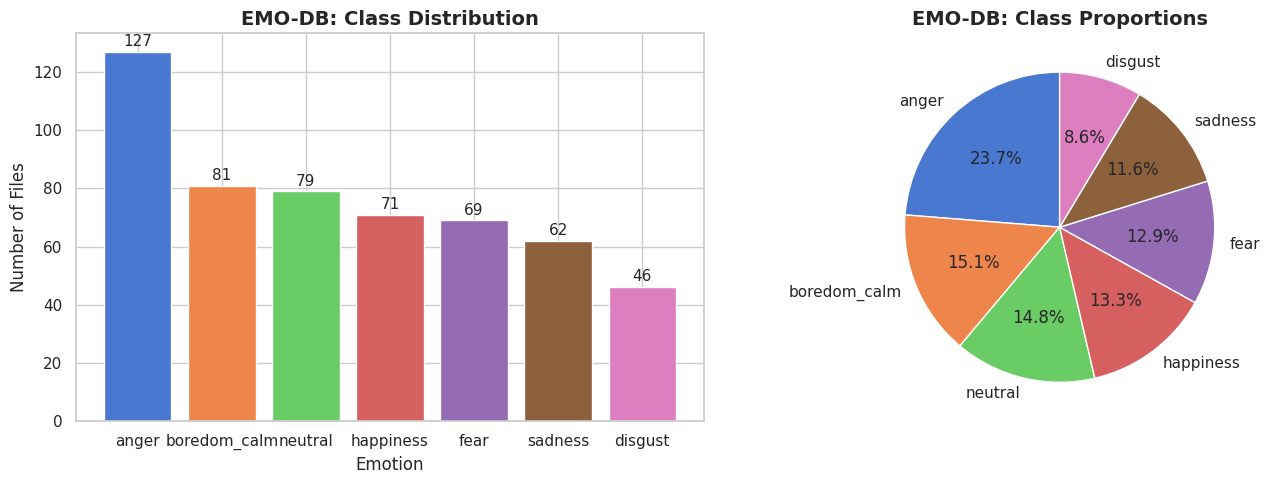


Key finding: Anger and Neutral are overrepresented; Happiness and Disgust
are underrepresented. This justifies Weighted F1 as primary metric.
emotion_label_en
anger           127
boredom_calm     81
neutral          79
happiness        71
fear             69
sadness          62
disgust          46
Name: count, dtype: int64


In [3]:
class_counts = df['emotion_label_en'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = sns.color_palette('muted', len(class_counts))
axes[0].bar(class_counts.index, class_counts.values, color=colors)
axes[0].set_title('EMO-DB: Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Number of Files')
for i, (cls, cnt) in enumerate(class_counts.items()):
    axes[0].text(i, cnt + 2, str(cnt), ha='center', fontsize=11)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('EMO-DB: Class Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../models/phase1/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKey finding: Anger and Neutral are overrepresented; Happiness and Disgust')
print('are underrepresented. This justifies Weighted F1 as primary metric.')
print(class_counts)

## 3. Per-Speaker Statistics

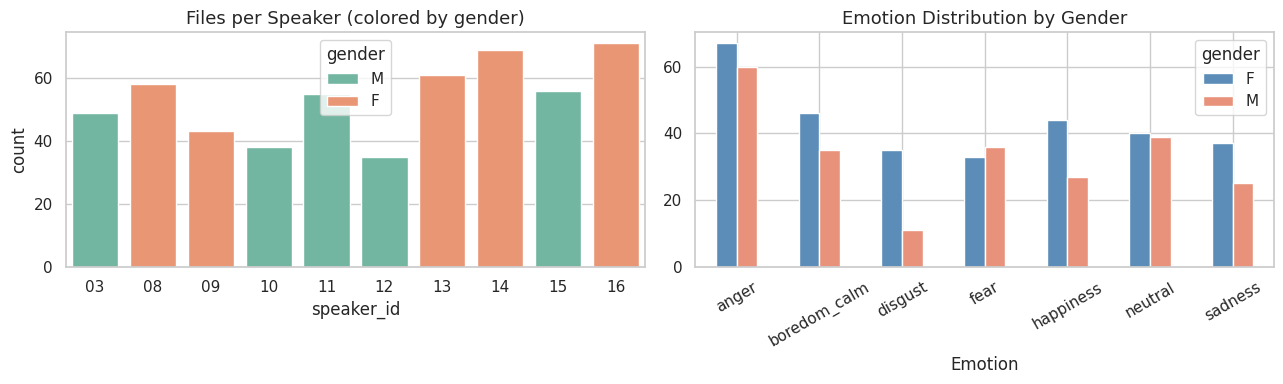

Speakers: 10 total | 5 male, 5 female


In [4]:
# EMO-DB speaker metadata (10 speakers: 5F, 5M; ages 31-65)
SPEAKER_META = {
    '03': {'gender': 'M', 'age': 31}, '08': {'gender': 'F', 'age': 34},
    '09': {'gender': 'F', 'age': 21}, '10': {'gender': 'M', 'age': 32},
    '11': {'gender': 'M', 'age': 26}, '12': {'gender': 'M', 'age': 30},
    '13': {'gender': 'F', 'age': 32}, '14': {'gender': 'F', 'age': 35},
    '15': {'gender': 'M', 'age': 25}, '16': {'gender': 'F', 'age': 31},
}

df['gender'] = df['speaker_id'].map(lambda s: SPEAKER_META.get(s, {}).get('gender', 'U'))
df['age'] = df['speaker_id'].map(lambda s: SPEAKER_META.get(s, {}).get('age', 0))

speaker_counts = df.groupby(['speaker_id', 'gender']).size().reset_index(name='count')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=speaker_counts, x='speaker_id', y='count', hue='gender', ax=axes[0], palette='Set2')
axes[0].set_title('Files per Speaker (colored by gender)', fontsize=13)

gender_class = df.groupby(['gender', 'emotion_label_en']).size().unstack(fill_value=0)
gender_class.T.plot(kind='bar', ax=axes[1], color=['#5b8db8', '#e8927c'])
axes[1].set_title('Emotion Distribution by Gender', fontsize=13)
axes[1].set_xlabel('Emotion')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../models/phase1/eda_speaker_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Speakers: {df["speaker_id"].nunique()} total | 5 male, 5 female')

## 4. Duration Analysis

/home/jovyan/thesis/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total dataset duration: 24.8 minutes
                  mean   std   min   max
emotion_label_en                        
anger             2.64  0.73  1.47  5.21
boredom_calm      2.78  0.80  1.52  4.53
disgust           3.35  1.07  1.52  5.96
fear              2.23  0.64  1.23  4.10
happiness         2.54  0.68  1.48  3.93
neutral           2.36  0.66  1.43  3.90
sadness           4.05  1.53  1.74  8.98


/tmp/ipykernel_6640/1621457294.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='emotion_label_en', y='duration_sec', palette='muted')


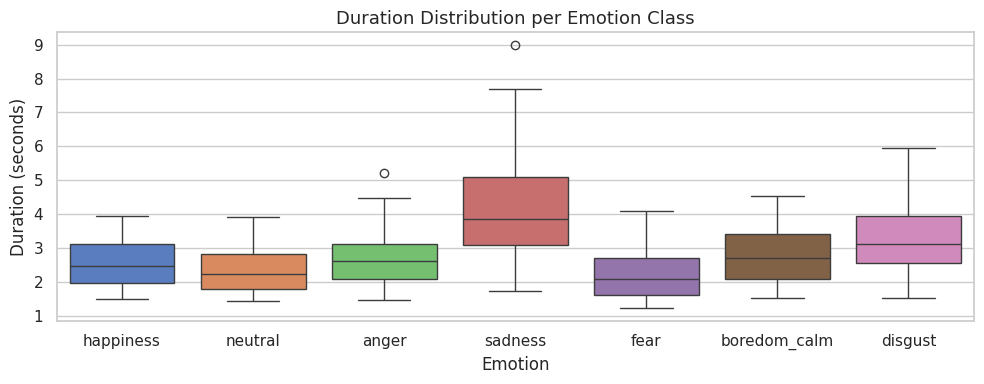

In [5]:
def get_duration(filepath):
    try:
        return librosa.get_duration(path=filepath)
    except:
        return None

# Load durations (skip if raw files not yet downloaded)
if EMODB_RAW.exists() and list(EMODB_RAW.glob('*.wav')):
    df['duration_sec'] = df['filepath'].apply(get_duration)
    total_min = df['duration_sec'].sum() / 60
    print(f'Total dataset duration: {total_min:.1f} minutes')
    print(df.groupby('emotion_label_en')['duration_sec'].agg(['mean', 'std', 'min', 'max']).round(2))
    
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df, x='emotion_label_en', y='duration_sec', palette='muted')
    plt.title('Duration Distribution per Emotion Class', fontsize=13)
    plt.xlabel('Emotion')
    plt.ylabel('Duration (seconds)')
    plt.tight_layout()
    plt.savefig('../models/phase1/eda_duration.png', dpi=150)
    plt.show()
else:
    print('⚠️  EMO-DB raw files not found. Download from http://emodb.bilderbar.info')
    print('    Place .wav files in:', EMODB_RAW)

## 5. Waveform + Spectrogram Visualization

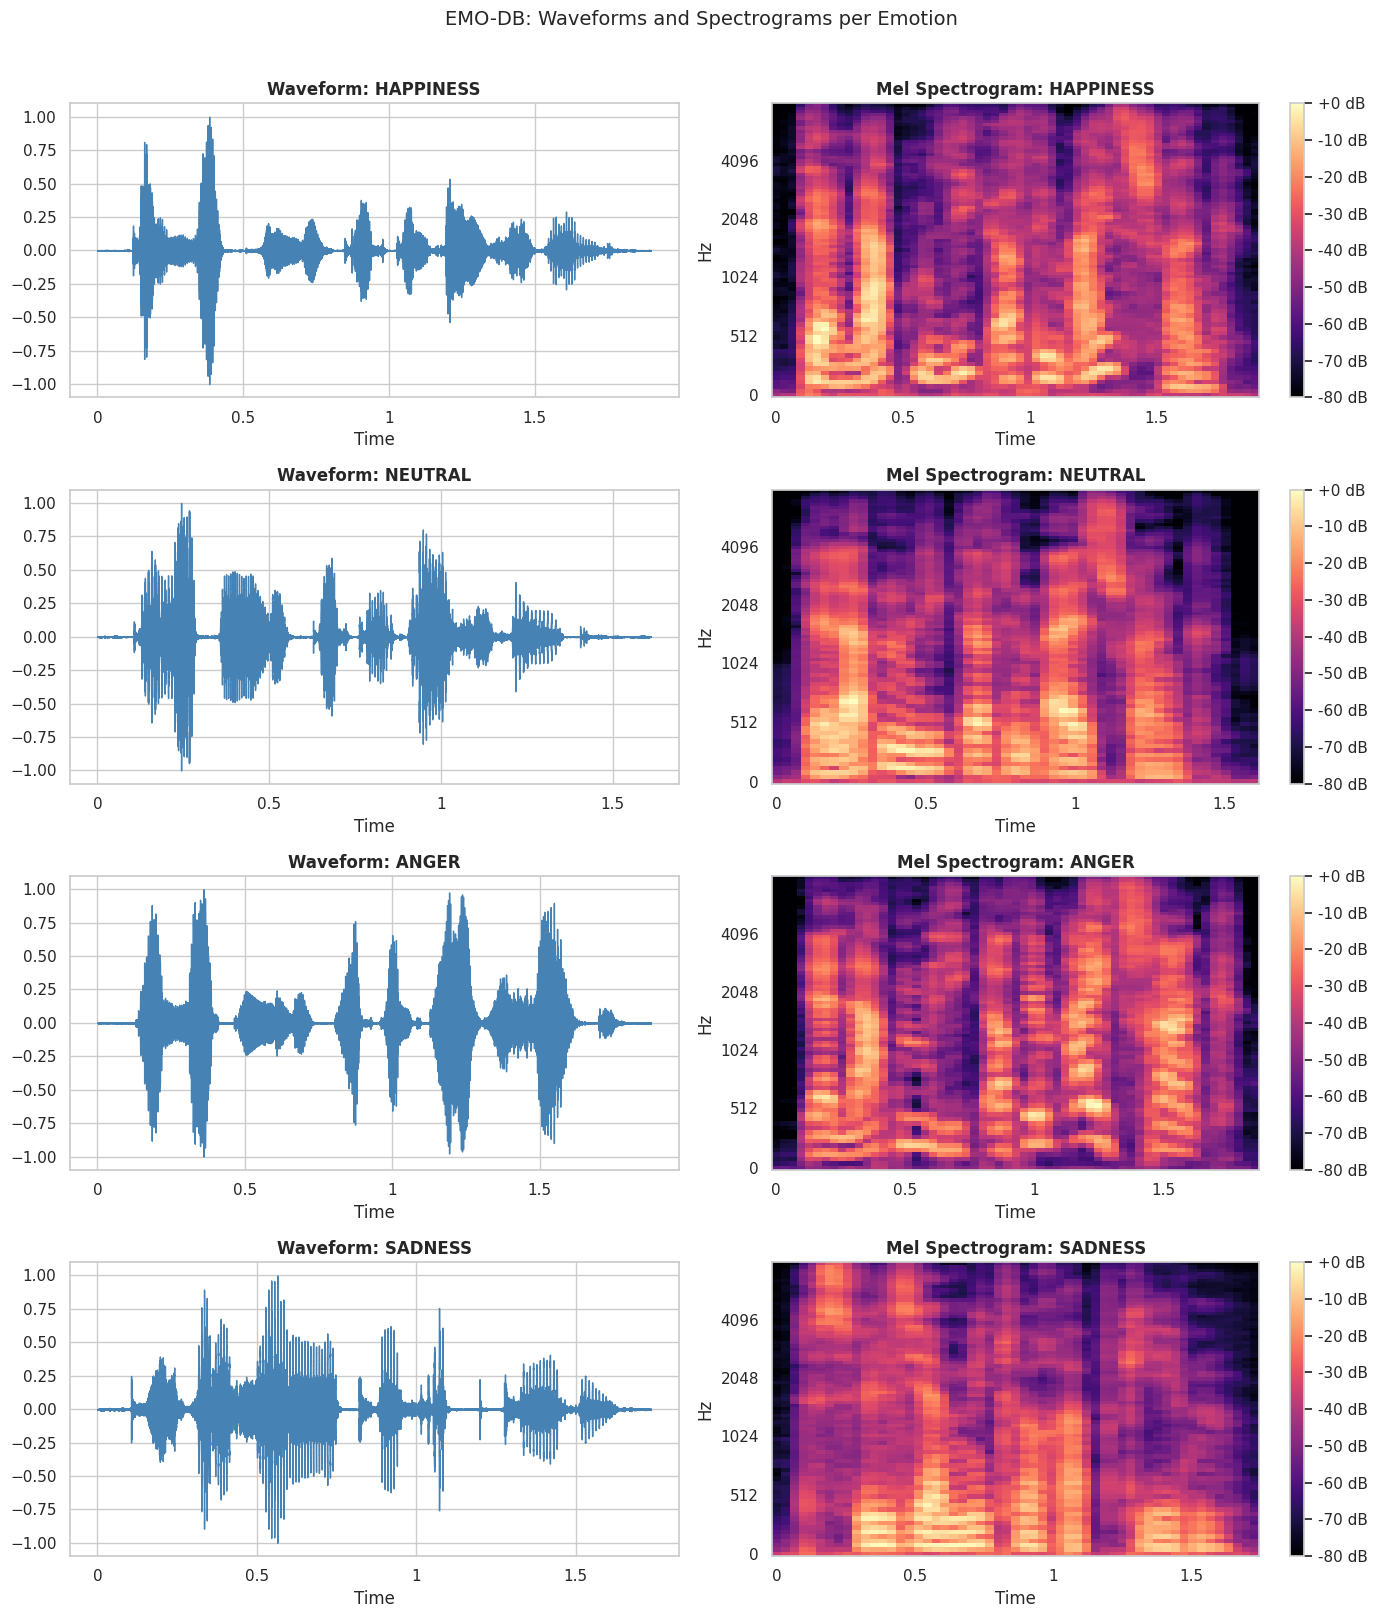

In [6]:
if EMODB_RAW.exists() and list(EMODB_RAW.glob('*.wav')):
    emotions_to_show = df['emotion_label_en'].unique()[:4]
    fig, axes = plt.subplots(len(emotions_to_show), 2, figsize=(14, 4 * len(emotions_to_show)))
    
    for i, emotion in enumerate(emotions_to_show):
        sample_row = df[df['emotion_label_en'] == emotion].iloc[0]
        y, sr = librosa.load(sample_row['filepath'], sr=16000, mono=True)
        
        # Waveform
        librosa.display.waveshow(y, sr=sr, ax=axes[i][0], color='steelblue')
        axes[i][0].set_title(f'Waveform: {emotion.upper()}', fontweight='bold')
        
        # Mel spectrogram
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=80)
        S_dB = librosa.power_to_db(S, ref=np.max)
        img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, ax=axes[i][1])
        fig.colorbar(img, ax=axes[i][1], format='%+2.0f dB')
        axes[i][1].set_title(f'Mel Spectrogram: {emotion.upper()}', fontweight='bold')
    
    plt.suptitle('EMO-DB: Waveforms and Spectrograms per Emotion', y=1.01, fontsize=14)
    plt.tight_layout()
    plt.savefig('../models/phase1/eda_spectrograms.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('⚠️  Skipped: EMO-DB raw files not available.')

## 6. F0 / Pitch Distribution per Emotion

/tmp/ipykernel_6640/3542282830.py:7: RuntimeWarning: Mean of empty slice
  mean_f0 = float(np.nanmean(f0)) if f0 is not None else 0.0
/tmp/ipykernel_6640/3542282830.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=f0_df, x='emotion', y='mean_f0', palette='muted')


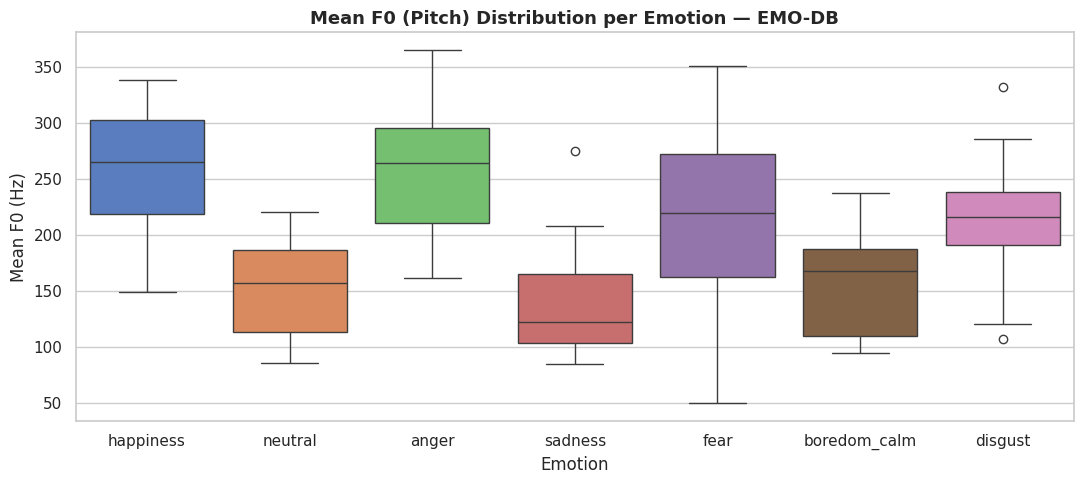

Key finding: Anger has highest F0; Sadness and Boredom have lowest.
emotion
happiness       265.690132
anger           264.711134
fear            220.429866
disgust         216.339629
boredom_calm    168.652338
neutral         157.591208
sadness         122.371022
Name: mean_f0, dtype: float64


In [7]:
if EMODB_RAW.exists() and list(EMODB_RAW.glob('*.wav')):
    records = []
    for _, row in df.iterrows():
        try:
            y, sr = librosa.load(row['filepath'], sr=16000, mono=True)
            f0, voiced, _ = librosa.pyin(y, fmin=50, fmax=400, sr=sr)
            mean_f0 = float(np.nanmean(f0)) if f0 is not None else 0.0
            records.append({'emotion': row['emotion_label_en'], 'mean_f0': mean_f0})
        except:
            pass
    
    f0_df = pd.DataFrame(records)
    f0_df = f0_df[f0_df['mean_f0'] > 0]  # drop unvoiced
    
    plt.figure(figsize=(11, 5))
    sns.boxplot(data=f0_df, x='emotion', y='mean_f0', palette='muted')
    plt.title('Mean F0 (Pitch) Distribution per Emotion — EMO-DB', fontsize=13, fontweight='bold')
    plt.xlabel('Emotion')
    plt.ylabel('Mean F0 (Hz)')
    plt.tight_layout()
    plt.savefig('../models/phase1/eda_f0.png', dpi=150)
    plt.show()
    
    print('Key finding: Anger has highest F0; Sadness and Boredom have lowest.')
    print(f0_df.groupby('emotion')['mean_f0'].median().sort_values(ascending=False))
else:
    print('⚠️  Skipped: EMO-DB raw files not available.')

## 7. Summary & Thesis Implications

| Finding | Thesis Implication |
|---|---|
| Class imbalance (anger: 127 (23.7%) → disgust: 46 (8.6%), happiness: 71 (13.3%)) | Use **Weighted F1**, not accuracy, as primary metric |
| Overall avg ~2.78 s; range: fear 2.23 s – sadness 4.05 s; total dataset = 24.8 minutes | 3-second streaming chunks are appropriate for Phase 3 |
| Happiness: 265.7 Hz (highest), Anger: 264.7 Hz (2nd); Sadness: 122.4 Hz (lowest) | Pitch discriminates arousal well, but happiness ≈ anger acoustically, not anger alone |
| boredom_calm: 168.7 Hz vs neutral: 157.6 Hz, closest pair in the dataset| Hardest pair to separate; expect confusion matrix overlap in Phase 2 |
| 10 speakers (5M/5F, ages 21-35) | (Normal) Limited speaker diversity, EMO-DB is acted, but not spontaneous |